## Multiscale contextualization of hippocampal gene expression gradients

**Overview**

In this tutorial, we will assess how the principal axes of transcriptomic organization align with multimodal/multiscale features of the hippocampus.

**0 - Import libraries**

In [ ]:
import os
import sys 

import hippomaps as hm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns

from brainspace.gradient import GradientMaps
from brainspace.mesh.mesh_io import read_surface
from cmcrameri import cm

sys.path.append(os.path.abspath(".."))
import hippogenes as hg

**1 - Load gene expression data and gradients**

In [51]:
expression = hg.load_expression(data_dir=".")

In [86]:
# Diffusion map embedding:
#gm = GradientMaps(n_components=5, kernel="normalized_angle", approach="dm")
#gm = gm.fit(np.array(expression), sparsity=0.9)

gradients = nib.load("/Users/alexngo/Downloads/gene_gradients.shape.gii").darrays[0].data

**2 - Load HippoMaps features**

In [44]:
maps_dir = os.path.join(".", "data")
files = [
    # Histology
    "histology-Bieloschowsky_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Blockface_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Calbindin_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Calretinin_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Merker_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Parvalbumin_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    
    # Imaging
    "MRI-3T-rsfMRI-FCG1to5_average-80_hemi-L_den-2mm_label-hipp.shape.gii",
    "MRI-3T-curvature_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-thickness_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-gyrification_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-DTI-FA_average-82.0_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-DTI-ADC_average-82.0_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-qT1_average-89.0_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-7T-T2star_average-20_hemi-mix_den-0p5mm_label-hipp.shape.gii",
 ]

In [45]:
features = []
densities = []
cdata = []
for i, f in enumerate(files):    
    
    feat = f.split("_")[0].split("-")[-1]
    den = f.split("den-")[1].split("_")[0]
    
    gii = nib.load(os.path.join(maps_dir, f)).darrays[0].data

    if feat == "FCG1to5":
        cdata.append(gii[:,0])
        cdata.append(gii[:,1])

        features.append(f"{feat}_grad1")
        features.append(f"{feat}_grad2")
        densities.append(den)
        densities.append(den)
    else: 
        cdata.append(gii)
        densities.append(den)
        features.append(feat)


/Users/alexngo/Repositories/toolboxes/hippogenes/.conda/lib/python3.9/site-packages/brainspace/plotting/surface_plotting.py:437: RuntimeWarning: Running plot_hemispheres without a display may result in a crash. For a workaround please consult https://github.com/MICA-MNI/BrainSpace/issues/66. To suppress this warning set suppress_warnings=True.
  warnings.warn(
Context leak detected, CoreAnalytics returned false


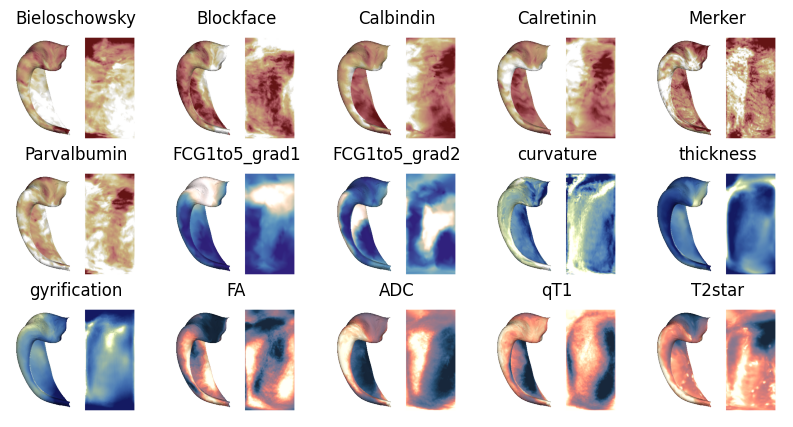

In [72]:
cmap = {
        # Histoloty
        "Bieloschowsky": cm.bilbao, 
        "Blockface": cm.bilbao, 
        "Parvalbumin": cm.bilbao, 
        "Calbindin": cm.bilbao, 
        "Calretinin": cm.bilbao,
        "Merker": cm.bilbao,
        
        # Morphology
        "curvature": cm.davos,
        "thickness": cm.davos,
        "gyrification": cm.davos,
        
        # Function
        "FCG1to5_grad1": cm.lapaz,
        "FCG1to5_grad2": cm.lapaz,
        
        # Microstructure
        "FA": cm.lipari,
        "ADC": cm.lipari,
        "qT1": cm.lipari,
        "T2star": cm.lipari
}
        

fig, ax = plt.subplots(3, 5, figsize=(10, 5))
for i, feat in enumerate(features):
    x = hm.utils.density_interp(densities[i], '0p5mm', cdata[i], label="hipp") if densities[i] != "0p5mm" else cdata[i]
    hm.plotting.surfplot_canonical_foldunfold(x, cmap=cmap[feat], hemis=["L"], labels=["hipp"], unfoldAPrescale=True, 
                                              share="row", tighten_cwindow=True, screenshot=True, filename=f"tmp_{i}.png")
    
    f = plt.imread(f"tmp_{i}.png")   
    ax[i//5, i%5].imshow(f)
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_anchor("NW")
    ax[i//5, i%5].set_title(feat)
    
!rm tmp_*.png


**3 - Correlate multimodal hippocampal maps with transcriptomic gradients**

In [87]:
# Statistical testing with spin permutation:bb
nperm = 1000

gene_contextualization = {}
for i in range(2):
    corr = np.full(len(cdata), np.nan)
    pval = np.full(len(cdata), np.nan)
    null = np.full((len(cdata), nperm), np.nan)

    for j, feat in enumerate(features):
        map1 = cdata[j]
        map2 = gradients[:,i]
        
        den = "0p5mm"
        if densities[j] == "2mm":
            map2 = hm.utils.density_interp('0p5mm', '2mm', map2, label="hipp")
            den = "2mm"
        elif densities[j] == "unfoldiso":
            map1 = hm.utils.density_interp("unfoldiso", '0p5mm', map1, label="hipp")
        
        null[j], _, pval[j], corr[j] = hm.stats.eigenstrapping(map2, map1, nperm=nperm, label="hipp", den=den)

    gene_contextualization[f"Gene_grad{i+1}"] = {
        "corr": corr,
        "pval": pval,
        "perm": null
    }

In [89]:
pd.DataFrame({k: gene_contextualization["Gene_grad1"][k] for k in ["corr", "pval"]}, index=features)

,corr,pval
Bieloschowsky,-0.054041,0.904
Blockface,0.080398,0.822
Calbindin,0.660251,0.020
Calretinin,0.599744,0.064
Merker,0.249242,0.420
Parvalbumin,0.508702,0.081
FCG1to5_grad1,-0.598376,0.075
FCG1to5_grad2,0.147774,0.695
curvature,0.090211,0.742
thickness,0.233916,0.376


(0.0, 1.0)

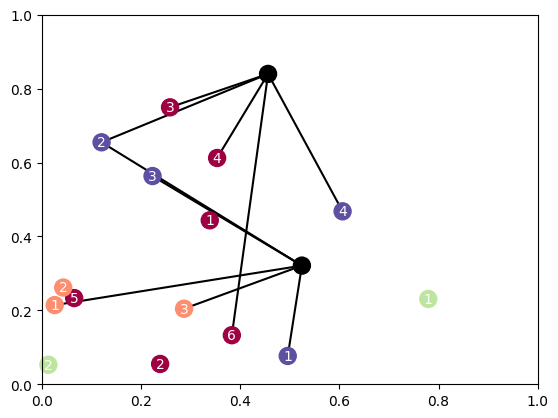

In [84]:
data = {
        #Transcriptomics
        "Gene_grad1": {"modality": "transcriptomics", "color": "#000000"},
        "Gene_grad2": {"modality": "transcriptomics", "color": "#000000"},

        # Histoloty
        "Bieloschowsky": {"modality": "histology", "color": "#9E0142"},
        "Blockface": {"modality": "histology", "color": "#9E0142"},
        "Parvalbumin": {"modality": "histology", "color": "#9E0142"},
        "Calbindin": {"modality": "histology", "color": "#9E0142"},
        "Calretinin": {"modality": "histology", "color": "#9E0142"},
        "Merker": {"modality": "histology", "color": "#9E0142"},
        
        # Morphology
        "curvature": {"modality": "morphology", "color": "#FD8E6F"},
        "thickness": {"modality": "morphology", "color": "#FD8E6F"},
        "gyrification": {"modality": "morphology", "color": "#FD8E6F"},
        
        # Function
        "FCG1to5_grad1": {"modality": "function", "color": "#BEE5A0"},
        "FCG1to5_grad2": {"modality": "function", "color": "#BEE5A0"},
        
        # Microstructure
        "FA": {"modality": "microstructure", "color": "#5E4FA2"},   
        "ADC": {"modality": "microstructure", "color": "#5E4FA2"},
        "qT1": {"modality": "microstructure", "color": "#5E4FA2"},
        "T2star": {"modality": "microstructure", "color": "#5E4FA2"}
}

hm_path = os.path.dirname(hm.__file__)

for i, grad in enumerate(gene_contextualization.keys()):
        surface = read_surface(os.path.join(hm_path, "resources", "canonical_surfs", "tpl-avg_space-unfold_den-0p5mm_label-hipp_midthickness.surf.gii"))
        ap_axis = surface.Points[:,0]
        ml_axis = surface.Points[:,1]
        data[grad]["ap_correlation"] = np.abs(np.corrcoef(gm.gradients_[:,i], ap_axis)[0,1])
        data[grad]["ml_correlation"] = np.abs(np.corrcoef(gm.gradients_[:,i], ml_axis)[0,1])

for i, feat in enumerate(features):
        surface = read_surface(os.path.join(hm_path, "resources", "canonical_surfs", f"tpl-avg_space-unfold_den-{densities[i]}_label-hipp_midthickness.surf.gii"))
        ap_axis = surface.Points[:,0]
        ml_axis = surface.Points[:,1]
        data[feat]["ap_correlation"] = np.abs(np.corrcoef(cdata[i], ap_axis)[0,1])
        data[feat]["ml_correlation"] = np.abs(np.corrcoef(cdata[i], ml_axis)[0,1])

colors = [data[feat]["color"] for feat in data.keys()]
f, ax = plt.subplots()
sns.scatterplot(x=[data[feat]["ap_correlation"] for feat in data.keys()],
                y=[data[feat]["ml_correlation"] for feat in data.keys()],
                c=colors,
                edgecolor=colors,
                clip_on=False,
                s=150
                )

counter = {"transcriptomics": 0, "histology": 0, "morphology": 0, "function": 0, "microstructure": 0}
for i, grad in enumerate(gene_contextualization.keys()):
        counter[data[grad]["modality"]] += 1
        for j, feat in enumerate(features):
                counter[data[feat]["modality"]] += 1
                if i < 1:
                        ax.text(data[feat]["ap_correlation"], 
                                data[feat]["ml_correlation"], 
                                counter[data[feat]["modality"]], 
                                ha='center', va='center',
                                c='w')
                if gene_contextualization[grad]["pval"][j] < 0.05:
                        ax.plot([data[grad]["ap_correlation"], data[feat]["ap_correlation"]],
                                [data[grad]["ml_correlation"], data[feat]["ml_correlation"]], 
                                'k-', zorder=-1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
